In [1]:
packages <- c("ggplot2", "dplyr")
for (pkg in packages) {
  suppressPackageStartupMessages(
    suppressWarnings(
      library(pkg, character.only = TRUE)
    )
  )
}


In [2]:
figures_path <- file.path("../figures/NF0014/")
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()

    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }

    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }

    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()



In [3]:
cell_counts_path_dir <- file.path(root_dir, "1.EDA/results/cell_counts")
cell_counts_figure_path <- file.path(root_dir, "1.EDA/figures/cell_counts")
if (!dir.exists(cell_counts_figure_path)) {
    dir.create(cell_counts_figure_path, recursive = TRUE)
}
if (!dir.exists(cell_counts_figure_path)) {
    dir.create(cell_counts_figure_path, recursive = TRUE)
}

In [4]:
# get all the cell counts files
cell_counts_files <- list.files(cell_counts_path_dir, pattern = "*.parquet", full.names = TRUE)
# read in all the cell counts files and combine them into a single data frame
cell_counts_df <- lapply(cell_counts_files, arrow::read_parquet) %>%
    bind_rows()
dim(cell_counts_df)

[1] 3483    9

In [5]:
add_feature_type <- function(df, x) {
    #' Add a column to the input data frame that classifies each profile by feature type.
    #'
    #' This function takes a data frame and adds a new column called `Metadata_feature_type`
    #' that classifies each profile based on the values in the `Metadata_profile_type` column. The classification is done using a series of conditions that check for specific keywords in the `Metadata_profile
    col_vals <- df[[x]]
    df %>%
        mutate(
            Metadata_feature_type = dplyr::case_when(
                # nucleocentric and sammed
                grepl("sammed", col_vals, ignore.case = TRUE) 
                & grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                ~ "Nucleocentric DL (SAMMed3D)",

                grepl("morphem", col_vals, ignore.case = TRUE) 
                & grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                ~ "Nucleocentric DL (MorphEM)",

                grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc DL (SAMMed3D)",

                grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid DL (SAMMed3D)",

                !grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("3D", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc Handcrafted (ZedProfiler)",

                !grepl("sammed", col_vals, ignore.case = TRUE) 
                & !grepl("nucleocentric", col_vals, ignore.case = TRUE) 
                & grepl("3D", col_vals, ignore.case = TRUE) 
                & grepl("organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid Handcrafted (ZedProfiler)",

            

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("max", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc 2D Max Projection",
                
                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("max", col_vals, ignore.case = TRUE) 
                & grepl("Organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid 2D Max Projection",
                

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_slice", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc 2D Middle Slice",
                
                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_slice", col_vals, ignore.case = TRUE) 
                & grepl("Organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid 2D Middle Slice",

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_n", col_vals, ignore.case = TRUE) 
                & grepl("sc", col_vals, ignore.case = TRUE)
                ~ "Sc 2D Middle 3 Slices",

                grepl("2D", col_vals, ignore.case = TRUE) 
                & grepl("middle_n", col_vals, ignore.case = TRUE) 
                & grepl("Organoid", col_vals, ignore.case = TRUE)
                ~ "Organoid 2D Middle 3 Slices",
                TRUE ~ "other"
            )
        )
}


cell_counts_df <- add_feature_type(cell_counts_df, "Metadata_profile_name")
cell_counts_df$sc_or_organoid <- "other"
cell_counts_df$sc_or_organoid <- dplyr::case_when(
    grepl("organoid", cell_counts_df$Metadata_profile_name, ignore.case = TRUE) ~ "organoid",
    grepl("(^|_)sc(_|$)", cell_counts_df$Metadata_profile_name, ignore.case = TRUE) ~ "sc",
    grepl("(^|_)nucleocentric(_|$)", cell_counts_df$Metadata_profile_name, ignore.case = TRUE) ~ "nucleocentric",
    TRUE ~ "other"
)
unique(cell_counts_df$Metadata_feature_type)
unique(cell_counts_df$Metadata_profile_name)
unique(cell_counts_df$sc_or_organoid)

[1] "Nucleocentric DL (MorphEM)"         "Organoid Handcrafted (ZedProfiler)"
 [3] "Organoid 2D Max Projection"         "Organoid 2D Middle 3 Slices"       
 [5] "Organoid 2D Middle Slice"           "Nucleocentric DL (SAMMed3D)"       
 [7] "Organoid DL (SAMMed3D)"             "Sc DL (SAMMed3D)"                  
 [9] "Sc Handcrafted (ZedProfiler)"       "Sc 2D Max Projection"              
[11] "Sc 2D Middle 3 Slices"              "Sc 2D Middle Slice"

[1] "nucleocentric_morphem_norm_norm_profile_3D"
 [2] "organoid_norm_norm_profile_3D"             
 [3] "organoid_profiles_2D_max_projection"       
 [4] "organoid_profiles_2D_middle_n_slice"       
 [5] "organoid_profiles_2D_middle_slice"         
 [6] "sammed_nucleocentric_norm_norm_profile_3D" 
 [7] "sammed_organoid_norm_norm_profile_3D"      
 [8] "sammed_sc_norm_norm_profile_3D"            
 [9] "sc_norm_norm_profile_3D"                   
[10] "sc_profiles_2D_max_projection"             
[11] "sc_profiles_2D_middle_n_slice"             
[12] "sc_profiles_2D_middle_slice"

[1] "nucleocentric" "organoid"      "sc"

Warning message:
“package ‘patchwork’ was built under R version 4.2.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.2.3”
Warning message:
“Removed 42 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 75 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 39 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 42 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 75 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 39 rows containing non-finite outside the scale range
(`stat_density()`).”


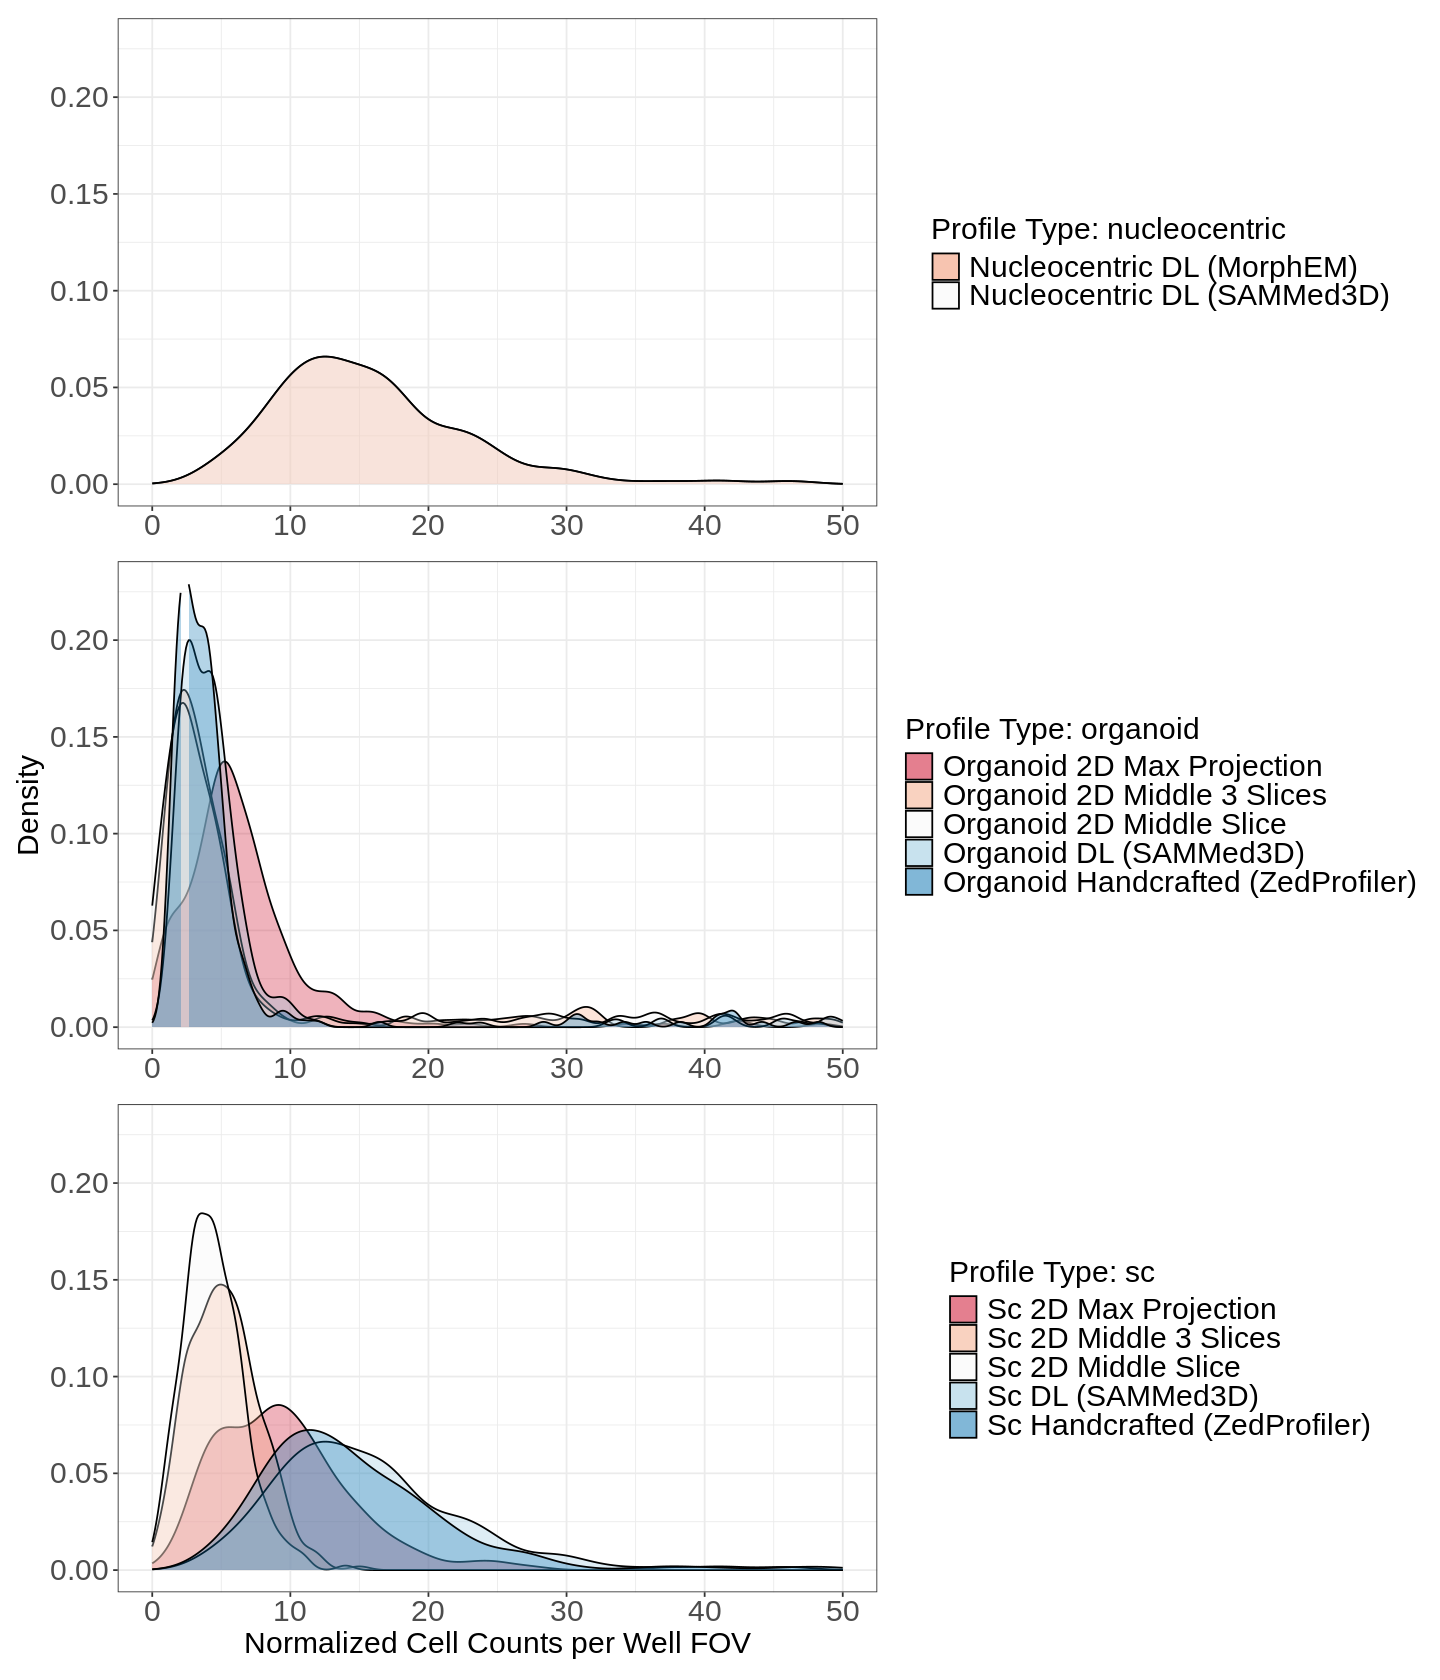

In [6]:
library(patchwork)
library(RColorBrewer)

width <- 12
height <- 14
options(repr.plot.width = width, repr.plot.height = height)

# compute the max density across all facet levels so y-axis can be shared
max_density <- cell_counts_df %>%
    filter(!is.na(Metadata_n_cells_norm_by_well_fov)) %>%
    group_by(sc_or_organoid, Metadata_feature_type) %>%
    summarise(
        dens = list(density(Metadata_n_cells_norm_by_well_fov, na.rm = TRUE)$y),
        .groups = "drop"
    ) %>%
    pull(dens) %>%
    unlist() %>%
    max()

make_density_plot <- function(data, facet_val, y_max) {
    ggplot(
        data %>% filter(sc_or_organoid == facet_val),
        aes(x = Metadata_n_cells_norm_by_well_fov, fill = Metadata_feature_type)
    ) +
        geom_density(alpha = 0.3) +
        xlim(0, 50) +
        ylim(0, y_max) +
        theme_bw() +
        theme(legend.position = "right") +
        labs(
            x = "Normalized Cell Counts per Well FOV",
            y = "Density",
            fill = paste0("Profile Type: ", facet_val)
        ) +
        guides(
            fill = guide_legend(override.aes = list(alpha = 0.5))
        ) +
        # diverging palette instead of default hues
        scale_fill_brewer(palette = "RdBu") +
        theme(
            axis.text = element_text(size = 18),
            axis.title = element_text(size = 18),
            strip.text = element_text(size = 18),
            plot.title = element_text(size = 18, face = "bold"),
            legend.title = element_text(size = 18),
            legend.text = element_text(size = 18)
        )
}

facet_levels <- unique(cell_counts_df$sc_or_organoid)

plot_list <- lapply(facet_levels, function(fv) make_density_plot(cell_counts_df, fv, max_density))

cell_count_density_plot <- wrap_plots(plot_list, ncol = 1) +
    plot_layout(axis_titles = "collect")
ggsave(
    filename = file.path(cell_counts_figure_path, "cell_count_density_plot.png"),
    plot = cell_count_density_plot,
    width = width,
    height = height,
    dpi = 600
)
cell_count_density_plot

Warning message:
“Removed 239 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette RdBu is 11
Returning the palette you asked for with that many colors
”
Warning message:
“Removed 239 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette RdBu is 11
Returning the palette you asked for with that many colors
”


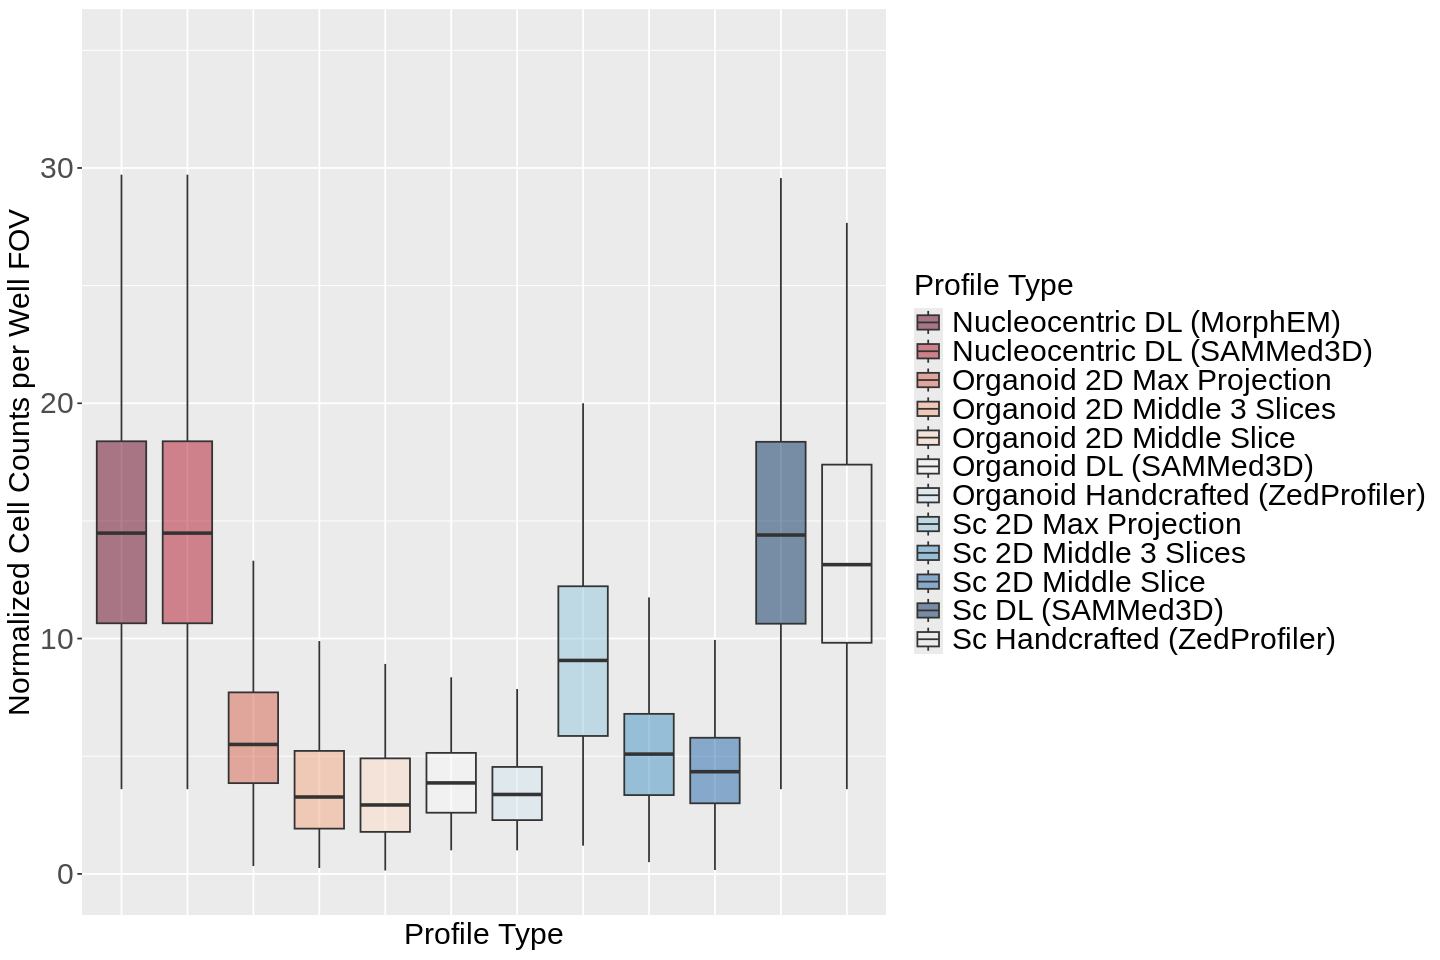

In [7]:
width <- 12
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
# summary_boxplot per feature type and sc_or_organoid
summary_plot <- (
    ggplot(
        cell_counts_df,
        aes(x = Metadata_feature_type, y = Metadata_n_cells_norm_by_well_fov, fill = Metadata_feature_type)
    )
    + geom_boxplot(outlier.shape = NA, alpha = 0.5)
    + ylim(0, 35)
    + scale_fill_brewer(palette = "RdBu")
    + labs(
        x = "Profile Type",
        y = "Normalized Cell Counts per Well FOV",
        fill = "Profile Type"
    )
    + theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        legend.title = element_text(size = 18),
        legend.text = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title = element_text(size = 18),
    )
)
ggsave(
    filename = file.path(cell_counts_figure_path, "cell_count_summary_boxplot.png"),
    plot = summary_plot,
    width = width,
    height = height,
    dpi = 600
)
summary_plot